In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("driver_standings.csv")

print(df.head())

   driverStandingsId  raceId  driverId  points  position positionText  wins
0                  1      18         1    10.0         1            1     1
1                  2      18         2     8.0         2            2     0
2                  3      18         3     6.0         3            3     0
3                  4      18         4     5.0         4            4     0
4                  5      18         5     4.0         5            5     0


In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34863 entries, 0 to 34862
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driverStandingsId  34863 non-null  int64  
 1   raceId             34863 non-null  int64  
 2   driverId           34863 non-null  int64  
 3   points             34863 non-null  float64
 4   position           34863 non-null  int64  
 5   positionText       34863 non-null  object 
 6   wins               34863 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 1.9+ MB
None

Missing Values:
driverStandingsId    0
raceId               0
driverId             0
points               0
position             0
positionText         0
wins                 0
dtype: int64


In [6]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

driverStandingsId    0
raceId               0
driverId             0
points               0
position             0
positionText         0
wins                 0
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After Removal:", df.duplicated().sum())

Duplicate Rows: 0
Duplicate Rows After Removal: 0


In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

driverStandingsId: 0 outliers
raceId: 0 outliers
driverId: 0 outliers
points: 4946 outliers
position: 1863 outliers
wins: 4199 outliers


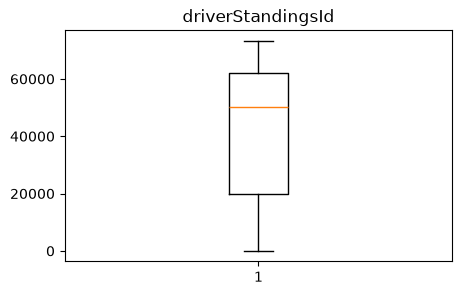

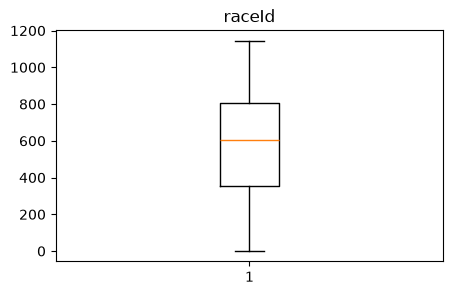

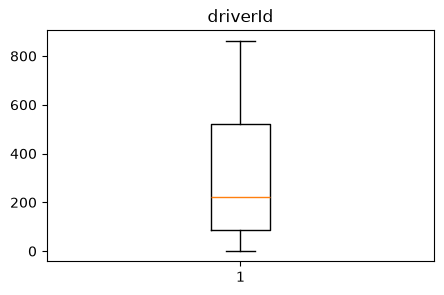

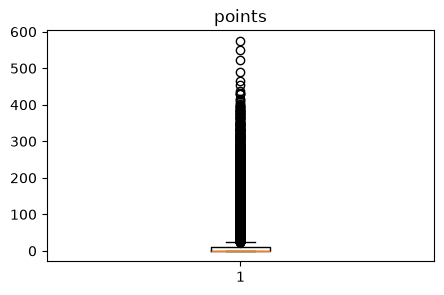

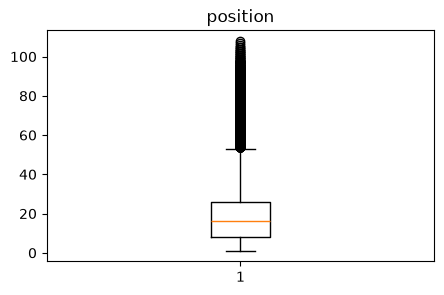

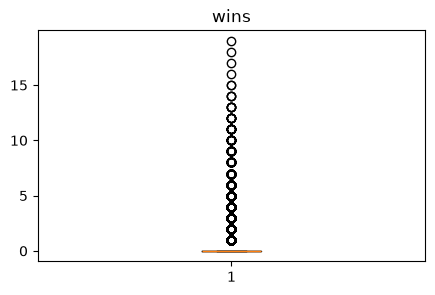

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()
    

In [10]:
scaler = MinMaxScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

   driverStandingsId    raceId  driverId    points  position positionText  \
0           0.000000  0.014873  0.000000  0.017391  0.000000            1   
1           0.000014  0.014873  0.001161  0.013913  0.009346            2   
2           0.000027  0.014873  0.002323  0.010435  0.018692            3   
3           0.000041  0.014873  0.003484  0.008696  0.028037            4   
4           0.000055  0.014873  0.004646  0.006957  0.037383            5   

       wins  
0  0.052632  
1  0.000000  
2  0.000000  
3  0.000000  
4  0.000000  


In [11]:
label = LabelEncoder()

df["positionText"] = label.fit_transform(df["positionText"])

print(df.head())

   driverStandingsId    raceId  driverId    points  position  positionText  \
0           0.000000  0.014873  0.000000  0.017391  0.000000             0   
1           0.000014  0.014873  0.001161  0.013913  0.009346            20   
2           0.000027  0.014873  0.002323  0.010435  0.018692            31   
3           0.000041  0.014873  0.003484  0.008696  0.028037            42   
4           0.000055  0.014873  0.004646  0.006957  0.037383            53   

       wins  
0  0.052632  
1  0.000000  
2  0.000000  
3  0.000000  
4  0.000000  


In [12]:
label = LabelEncoder()

df["positionText"] = label.fit_transform(df["positionText"])

print(df.head())

   driverStandingsId    raceId  driverId    points  position  positionText  \
0           0.000000  0.014873  0.000000  0.017391  0.000000             0   
1           0.000014  0.014873  0.001161  0.013913  0.009346            20   
2           0.000027  0.014873  0.002323  0.010435  0.018692            31   
3           0.000041  0.014873  0.003484  0.008696  0.028037            42   
4           0.000055  0.014873  0.004646  0.006957  0.037383            53   

       wins  
0  0.052632  
1  0.000000  
2  0.000000  
3  0.000000  
4  0.000000  


In [13]:
print(df.dtypes)

driverStandingsId    float64
raceId               float64
driverId             float64
points               float64
position             float64
positionText           int64
wins                 float64
dtype: object


In [14]:
print(df.head())

   driverStandingsId    raceId  driverId    points  position  positionText  \
0           0.000000  0.014873  0.000000  0.017391  0.000000             0   
1           0.000014  0.014873  0.001161  0.013913  0.009346            20   
2           0.000027  0.014873  0.002323  0.010435  0.018692            31   
3           0.000041  0.014873  0.003484  0.008696  0.028037            42   
4           0.000055  0.014873  0.004646  0.006957  0.037383            53   

       wins  
0  0.052632  
1  0.000000  
2  0.000000  
3  0.000000  
4  0.000000  
